
# AGP vs UKB analytic sample comparison for Section 4.6

This notebook recreates and updates the AGP–UKB distribution-comparison workflow using the **current RF/PCA projection pipeline** and the updated **UKB → AGP recoding**.

## Main goals
1. Reproduce the **UKB analytic sample** using the same row-filtering logic as the updated `projection_RF_PCA` notebook.
2. Compare **shared harmonized predictors** between AGP and the filtered UKB sample.
3. Generate a **thesis-ready selected-variable figure** showing that the recoded UKB variables are broadly comparable to AGP.
4. Load or regenerate **projected microbiome PCs** in UKB and summarize their distributions.

## Expected outputs
Saved under:

`./hongrui_result/UKB_RF_PCA_Projection/analytic_sample_agp_ukb_comparison/`

Including:
- `sample_flow_ukb.csv`
- `compact_demographics_agp_vs_ukb.csv`
- `all_shared_traincols_drift_summary.csv`
- `all_shared_traincols_distributions.pdf`
- `selected_variable_drift_summary.csv`
- `selected_AGP_vs_UKB_variables.pdf`
- `selected_AGP_vs_UKB_variables.png`
- `ukb_projected_pcs_summary.csv`
- `ukb_projected_pc_distributions.pdf/png`
- `ukb_projected_pc_corr_heatmap.pdf/png`

## Notes
- This notebook follows the **updated RF/PCA projection notebook** for row filtering and UKB prediction setup.
- It is designed to be robust: if projected PCs already exist, it loads them; otherwise it rebuilds them from the saved RF models.
- AGP metadata are restricted to samples that overlap the AGP OTU table when the OTU file is available, matching the model-development base cohort as closely as possible.


In [1]:

from pathlib import Path
import json
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# -----------------------------
# Paths
# -----------------------------
os.chdir('/scratch/liuhon33/parallel/AGPMicrobiomeHostPredictions')
model_dir = Path("./RF_PCA_Trained_Models")
projection_out_dir = Path("./hongrui_result/UKB_RF_PCA_Projection")
comparison_out_dir = projection_out_dir / "analytic_sample_agp_ukb_comparison"
comparison_out_dir.mkdir(parents=True, exist_ok=True)

ukb_metadata_path = Path("variable_mapping/ukb_as_agp_metadata.csv")
agp_metadata_path = Path("./Data/Cleaned_data/processed_metadata.csv")
agp_otu_path = Path("./Data/Cleaned_data/AGP_Otu_Data.csv")

ukb_index_col = "sample_name"
agp_index_col = "sample_name"
otu_index_col = 0

# -----------------------------
# Updated projection settings
# -----------------------------
cognition_col = "fluid_intelligence_score"

cov_num = ["age_corrected"]
cov_cat = ["race", "highest_education"]  # matches current updated projection_RF_PCA notebook

skip_cols = [
    "cat",
    "dog",
    "multivitamin",
    "other_supplement_frequency",
    "cosmetics_frequency",
    "fermented_plant_frequency",
    "homecooked_meals_frequency",
    "meat_eggs_frequency",
    "sugary_sweets_frequency",
    "vivid_dreams",
    "sugar_sweetened_drink_frequency",
    "artificial_sweeteners",
    "olive_oil",
    "prepared_meals_frequency",
    "ready_to_eat_meals_frequency",
    "whole_eggs",
    "frozen_dessert_frequency",
]

max_missing_frac = 0.15
required_for_regression = [cognition_col] + cov_num

# Thesis-ready selected variables
selected_vars = [
    "age_corrected",
    "bmi",
    "fruit_frequency",
    "vegetable_frequency",
    "exercise_frequency",
    "alcohol_frequency",
    "smoking_frequency",
    "whole_grain_frequency",
    "red_meat_frequency",
    "milk_cheese_frequency",
    "sleep_duration",
    "bowel_movement_frequency",
]

categorical_keep = {"country_of_birth", "country", "race", "highest_education"}
top_k_categories = 20
numeric_bins = 30
treat_numeric_as_categorical_if_unique_leq = 15

print("comparison_out_dir =", comparison_out_dir)


comparison_out_dir = hongrui_result/UKB_RF_PCA_Projection/analytic_sample_agp_ukb_comparison


In [2]:

# -----------------------------
# Helper functions
# -----------------------------
def filter_rows_by_missingness(df, *, skip_cols=(), required_cols=(), max_missing_frac=0.15):
    skip_cols = list(skip_cols)
    required_cols = list(required_cols)

    missing_skip = [c for c in skip_cols if c not in df.columns]
    if missing_skip:
        print(f"[WARN] skip_cols not in dataframe (ignored): {missing_skip[:10]}{'...' if len(missing_skip) > 10 else ''}")

    cols_check = [c for c in df.columns if c not in set(skip_cols)]
    if len(cols_check) == 0:
        raise ValueError("After applying skip_cols, cols_check is empty. Reduce skip_cols.")

    missing_frac = df[cols_check].isna().mean(axis=1)
    n_in = df.shape[0]
    mask = missing_frac <= max_missing_frac
    df_f = df.loc[mask].copy()

    required_present = [c for c in required_cols if c in df_f.columns]
    df_f = df_f.dropna(subset=required_present)

    n_out = df_f.shape[0]
    report = {
        "n_in": int(n_in),
        "n_out": int(n_out),
        "dropped": int(n_in - n_out),
        "cols_check_n": int(len(cols_check)),
        "missing_frac_summary": missing_frac.describe().to_dict(),
    }
    return df_f, report


def force_numeric_everything_else(df: pd.DataFrame, categorical_keep: set) -> pd.DataFrame:
    df = df.copy()
    for c in df.columns:
        if c in categorical_keep:
            df[c] = df[c].astype("string")
        else:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def _as_categorical(series: pd.Series) -> pd.Series:
    return series.astype("string").fillna("MISSING")


def _tv_distance(p: pd.Series, q: pd.Series) -> float:
    return float(0.5 * np.abs(p.values - q.values).sum())


def _std_mean_diff(x: np.ndarray, y: np.ndarray) -> float:
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    mx, my = np.mean(x), np.mean(y)
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    sp = np.sqrt((sx**2 + sy**2) / 2.0)
    return float((my - mx) / sp) if sp > 0 else np.nan


def clean_num_tick(x):
    try:
        fx = float(x)
        if np.isfinite(fx) and fx.is_integer():
            return str(int(fx))
        return f"{fx:g}"
    except Exception:
        return str(x)


def summarize_distribution_shift(col, s_agp, s_ukb, *, categorical_keep, top_k_categories=20, discrete_threshold=15):
    out = {
        "column": col,
        "type": None,
        "agp_n_nonmissing": int(s_agp.notna().sum()),
        "ukb_n_nonmissing": int(s_ukb.notna().sum()),
        "tv_distance": np.nan,
        "std_mean_diff": np.nan,
    }

    if col in categorical_keep:
        c_agp = _as_categorical(s_agp)
        c_ukb = _as_categorical(s_ukb)

        vc_agp = c_agp.value_counts(normalize=True, dropna=False)
        vc_ukb = c_ukb.value_counts(normalize=True, dropna=False)

        top_union = list(pd.Index(vc_agp.head(top_k_categories).index).union(vc_ukb.head(top_k_categories).index))
        p = vc_agp.reindex(top_union, fill_value=0.0)
        q = vc_ukb.reindex(top_union, fill_value=0.0)

        avg = (p + q) / 2.0
        keep = avg.sort_values(ascending=False).head(top_k_categories).index

        p2 = p.reindex(keep, fill_value=0.0).copy()
        q2 = q.reindex(keep, fill_value=0.0).copy()

        p2.loc["Other"] = max(0.0, float(1.0 - p2.sum()))
        q2.loc["Other"] = max(0.0, float(1.0 - q2.sum()))

        out["type"] = "categorical"
        out["tv_distance"] = _tv_distance(p2 / max(p2.sum(), 1e-12), q2 / max(q2.sum(), 1e-12))
        return out

    nunq = int(max(s_agp.dropna().nunique(), s_ukb.dropna().nunique()))

    if nunq <= discrete_threshold:
        vc_agp = s_agp.dropna().value_counts(normalize=True)
        vc_ukb = s_ukb.dropna().value_counts(normalize=True)

        cats = sorted(set(vc_agp.index).union(set(vc_ukb.index)))
        p2 = vc_agp.reindex(cats, fill_value=0.0)
        q2 = vc_ukb.reindex(cats, fill_value=0.0)

        if len(cats) > top_k_categories:
            avg = (p2 + q2) / 2.0
            keep = avg.sort_values(ascending=False).head(top_k_categories).index
            p2 = p2.reindex(keep).copy()
            q2 = q2.reindex(keep).copy()
            p2.loc["Other"] = max(0.0, float(1.0 - p2.sum()))
            q2.loc["Other"] = max(0.0, float(1.0 - q2.sum()))

        out["type"] = "numeric_discrete"
        out["tv_distance"] = _tv_distance(p2 / max(p2.sum(), 1e-12), q2 / max(q2.sum(), 1e-12)) if (p2.sum() > 0 and q2.sum() > 0) else np.nan
        return out

    x = s_agp.dropna().astype(float).to_numpy()
    y = s_ukb.dropna().astype(float).to_numpy()
    out["type"] = "numeric_continuous"
    out["std_mean_diff"] = _std_mean_diff(x, y)
    return out


def make_distribution_page(ax1, ax2, col, s_agp, s_ukb, *, categorical_keep, top_k_categories=20, numeric_bins=30, discrete_threshold=15):
    if col in categorical_keep:
        c_agp = _as_categorical(s_agp)
        c_ukb = _as_categorical(s_ukb)

        vc_agp = c_agp.value_counts(normalize=True, dropna=False)
        vc_ukb = c_ukb.value_counts(normalize=True, dropna=False)

        top_union = list(pd.Index(vc_agp.head(top_k_categories).index).union(vc_ukb.head(top_k_categories).index))
        p = vc_agp.reindex(top_union, fill_value=0.0)
        q = vc_ukb.reindex(top_union, fill_value=0.0)

        avg = (p + q) / 2.0
        keep = avg.sort_values(ascending=False).head(top_k_categories).index

        p2 = p.reindex(keep, fill_value=0.0).copy()
        q2 = q.reindex(keep, fill_value=0.0).copy()
        p2.loc["Other"] = max(0.0, float(1.0 - p2.sum()))
        q2.loc["Other"] = max(0.0, float(1.0 - q2.sum()))

        ax1.bar(p2.index.astype(str), p2.values)
        ax2.bar(q2.index.astype(str), q2.values)
        ax1.set_title(f"AGP: {col} (n={int(c_agp.notna().sum())})")
        ax2.set_title(f"UKB: {col} (n={int(c_ukb.notna().sum())})")
        ax1.set_ylabel("Proportion")
        ax2.set_ylabel("Proportion")
        ax1.tick_params(axis="x", rotation=90)
        ax2.tick_params(axis="x", rotation=90)
        return

    nunq = int(max(s_agp.dropna().nunique(), s_ukb.dropna().nunique()))
    if nunq <= discrete_threshold:
        vc_agp = s_agp.dropna().value_counts(normalize=True)
        vc_ukb = s_ukb.dropna().value_counts(normalize=True)
        cats = sorted(set(vc_agp.index).union(set(vc_ukb.index)))

        p2 = vc_agp.reindex(cats, fill_value=0.0)
        q2 = vc_ukb.reindex(cats, fill_value=0.0)

        if len(cats) > top_k_categories:
            avg = (p2 + q2) / 2.0
            keep = avg.sort_values(ascending=False).head(top_k_categories).index
            p2 = p2.reindex(keep).copy()
            q2 = q2.reindex(keep).copy()
            p2.loc["Other"] = max(0.0, float(1.0 - p2.sum()))
            q2.loc["Other"] = max(0.0, float(1.0 - q2.sum()))

        labels = [clean_num_tick(x) if x != "Other" else "Other" for x in p2.index]
        p2.index = labels
        q2.index = labels

        ax1.bar(p2.index.astype(str), p2.values)
        ax2.bar(q2.index.astype(str), q2.values)
        ax1.set_title(f"AGP: {col} (n={int(s_agp.notna().sum())})")
        ax2.set_title(f"UKB: {col} (n={int(s_ukb.notna().sum())})")
        ax1.set_ylabel("Proportion")
        ax2.set_ylabel("Proportion")
        ax1.tick_params(axis="x", rotation=90)
        ax2.tick_params(axis="x", rotation=90)
        return

    x = s_agp.dropna().astype(float).to_numpy()
    y = s_ukb.dropna().astype(float).to_numpy()

    if len(x) == 0 or len(y) == 0:
        ax1.text(0.5, 0.5, f"No data\n{col}", ha="center", va="center")
        ax2.text(0.5, 0.5, f"No data\n{col}", ha="center", va="center")
        ax1.set_axis_off()
        ax2.set_axis_off()
        return

    combined = np.concatenate([x, y])
    bins = np.histogram_bin_edges(combined, bins=numeric_bins)

    ax1.hist(x, bins=bins)
    ax2.hist(y, bins=bins)
    lo, hi = float(np.nanmin(combined)), float(np.nanmax(combined))
    ax1.set_xlim(lo, hi)
    ax2.set_xlim(lo, hi)

    ax1.set_title(f"AGP: {col} (n={len(x)})")
    ax2.set_title(f"UKB: {col} (n={len(y)})")
    ax1.set_ylabel("Count")
    ax2.set_ylabel("Count")


def make_overlay_grid(agp_df, ukb_df, columns, out_png, out_pdf, *, categorical_keep, discrete_threshold=15, ncols=3):
    cols_present = [c for c in columns if c in agp_df.columns and c in ukb_df.columns]
    if len(cols_present) == 0:
        raise ValueError("None of the requested columns are shared between AGP and UKB.")

    nrows = int(np.ceil(len(cols_present) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.3 * ncols, 3.9 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols_present):
        s_agp = agp_df[col]
        s_ukb = ukb_df[col]

        if col in categorical_keep:
            c_agp = _as_categorical(s_agp)
            c_ukb = _as_categorical(s_ukb)

            vc_agp = c_agp.value_counts(normalize=True, dropna=False)
            vc_ukb = c_ukb.value_counts(normalize=True, dropna=False)
            cats = list(pd.Index(vc_agp.index).union(vc_ukb.index))
            cats = [x for x in cats if x != "MISSING"]
            if "MISSING" in set(vc_agp.index).union(vc_ukb.index):
                cats = cats + ["MISSING"]

            xloc = np.arange(len(cats))
            width = 0.42
            p = vc_agp.reindex(cats, fill_value=0.0)
            q = vc_ukb.reindex(cats, fill_value=0.0)

            ax.bar(xloc - width / 2, p.values, width=width, label="AGP")
            ax.bar(xloc + width / 2, q.values, width=width, label="UKB")
            ax.set_xticks(xloc)
            ax.set_xticklabels([str(c) for c in cats], rotation=45, ha="right")
            ax.set_ylabel("Proportion")
            ax.set_title(col)
            continue

        nunq = int(max(s_agp.dropna().nunique(), s_ukb.dropna().nunique()))
        if nunq <= discrete_threshold:
            vc_agp = s_agp.dropna().value_counts(normalize=True)
            vc_ukb = s_ukb.dropna().value_counts(normalize=True)
            cats = sorted(set(vc_agp.index).union(set(vc_ukb.index)))
            labels = [clean_num_tick(x) for x in cats]

            xloc = np.arange(len(cats))
            width = 0.42
            p = vc_agp.reindex(cats, fill_value=0.0)
            q = vc_ukb.reindex(cats, fill_value=0.0)

            ax.bar(xloc - width / 2, p.values, width=width, label="AGP")
            ax.bar(xloc + width / 2, q.values, width=width, label="UKB")
            ax.set_xticks(xloc)
            ax.set_xticklabels(labels, rotation=0)
            ax.set_ylabel("Proportion")
            ax.set_title(col)
            continue

        x = s_agp.dropna().astype(float).to_numpy()
        y = s_ukb.dropna().astype(float).to_numpy()
        if len(x) > 0 and len(y) > 0:
            combined = np.concatenate([x, y])
            bins = np.histogram_bin_edges(combined, bins=25)
            ax.hist(x, bins=bins, density=True, alpha=0.5, label="AGP")
            ax.hist(y, bins=bins, density=True, alpha=0.5, label="UKB")
            ax.set_ylabel("Density")
        ax.set_title(col)

    for ax in axes[len(cols_present):]:
        ax.set_axis_off()

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

    fig.suptitle("Selected harmonized variables: AGP vs filtered UKB", y=1.02, fontsize=15)
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def make_compact_demographics(agp_df, ukb_df):
    rows = []

    rows.append({"Variable": "N", "AGP": int(agp_df.shape[0]), "UKB": int(ukb_df.shape[0])})

    for col, label in [("age_corrected", "Age, years"), ("bmi", "BMI, kg/m²")]:
        if col in agp_df.columns and col in ukb_df.columns:
            a = pd.to_numeric(agp_df[col], errors="coerce")
            u = pd.to_numeric(ukb_df[col], errors="coerce")
            rows.append({
                "Variable": label,
                "AGP": f"{a.mean():.1f} ± {a.std():.1f}",
                "UKB": f"{u.mean():.1f} ± {u.std():.1f}",
            })

    if "sex" in agp_df.columns and "sex" in ukb_df.columns:
        a = pd.to_numeric(agp_df["sex"], errors="coerce")
        u = pd.to_numeric(ukb_df["sex"], errors="coerce")
        a_n = int(a.notna().sum())
        u_n = int(u.notna().sum())
        a_f = int((a == 1).sum())
        u_f = int((u == 1).sum())
        rows.append({
            "Variable": "Female sex",
            "AGP": f"{a_f} ({100 * a_f / max(a_n,1):.1f}%)",
            "UKB": f"{u_f} ({100 * u_f / max(u_n,1):.1f}%)",
        })

    if "race" in agp_df.columns and "race" in ukb_df.columns:
        a = agp_df["race"].astype("string")
        u = ukb_df["race"].astype("string")
        race_levels = ["Caucasian", "Asian or Pacific Islander", "African American", "Hispanic", "Other"]
        rows.append({"Variable": "Race / ethnicity", "AGP": "", "UKB": ""})
        for lvl in race_levels:
            a_ct = int((a == lvl).sum())
            u_ct = int((u == lvl).sum())
            rows.append({
                "Variable": f"  {lvl}",
                "AGP": f"{a_ct} ({100 * a_ct / max(int(a.notna().sum()),1):.1f}%)",
                "UKB": f"{u_ct} ({100 * u_ct / max(int(u.notna().sum()),1):.1f}%)",
            })

    if cognition_col in ukb_df.columns:
        y = pd.to_numeric(ukb_df[cognition_col], errors="coerce")
        rows.append({
            "Variable": "Fluid intelligence score",
            "AGP": "—",
            "UKB": f"{y.mean():.1f} ± {y.std():.1f}",
        })

    return pd.DataFrame(rows)


def load_or_predict_projected_pcs(ukb_df, train_cols, n_pcs_to_predict, final_rf_models, projection_out_dir):
    pred_path = projection_out_dir / "ukb_predicted_microbiome_pcs.csv"
    if pred_path.exists():
        print(f"Loading existing projected PCs from: {pred_path}")
        pc_hat = pd.read_csv(pred_path, index_col=0)
        return pc_hat

    print("Projected PC file not found. Recomputing projected PCs from saved RF models...")
    X_ukb = ukb_df.reindex(columns=train_cols).apply(pd.to_numeric, errors="coerce")

    missing_cols = [c for c in train_cols if c not in ukb_df.columns]
    print(f"UKB is missing {len(missing_cols)} / {len(train_cols)} training columns.")
    if len(missing_cols) > 0:
        print("First 25 missing training columns:", missing_cols[:25])

    missing_rate_before = float(np.mean(pd.isna(X_ukb.values)))
    print(f"Overall missing rate in X_ukb before UKB mean imputation: {missing_rate_before*100:.2f}%")

    ukb_col_means = X_ukb.mean(axis=0)
    X_ukb = X_ukb.fillna(ukb_col_means)

    missing_rate_after = float(np.mean(pd.isna(X_ukb.values)))
    print(f"Overall missing rate in X_ukb after UKB mean imputation: {missing_rate_after*100:.2f}%")

    pc_hat = pd.DataFrame(index=ukb_df.index)
    for k in range(n_pcs_to_predict):
        pc_name = f"PC{k+1}"
        if pc_name not in final_rf_models:
            raise KeyError(f"Model for {pc_name} not found in final_rf_models.pkl")
        pc_hat[f"{pc_name}_hat"] = final_rf_models[pc_name].predict(X_ukb)

    pc_hat.to_csv(pred_path)
    print(f"Saved projected PCs to: {pred_path}")
    return pc_hat


def summarize_projected_pcs(pc_hat):
    rows = []
    for col in pc_hat.columns:
        s = pd.to_numeric(pc_hat[col], errors="coerce")
        rows.append({
            "PC": col,
            "N": int(s.notna().sum()),
            "Mean": float(s.mean()),
            "SD": float(s.std()),
            "Median": float(s.median()),
            "Q1": float(s.quantile(0.25)),
            "Q3": float(s.quantile(0.75)),
            "Min": float(s.min()),
            "Max": float(s.max()),
        })
    return pd.DataFrame(rows)


def plot_projected_pc_distributions(pc_hat, out_png, out_pdf, max_show=10, ncols=3):
    pc_cols = [c for c in pc_hat.columns if c.endswith("_hat")][:max_show]
    nrows = int(np.ceil(len(pc_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, pc_cols):
        s = pd.to_numeric(pc_hat[col], errors="coerce").dropna()
        ax.hist(s, bins=30)
        ax.set_title(col)
        ax.set_ylabel("Count")
        ax.set_xlabel("Predicted score")

    for ax in axes[len(pc_cols):]:
        ax.set_axis_off()

    fig.suptitle("UKB projected microbiome PC distributions", y=1.02, fontsize=15)
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_projected_pc_corr(pc_hat, out_png, out_pdf, max_show=10):
    pc_cols = [c for c in pc_hat.columns if c.endswith("_hat")][:max_show]
    corr = pc_hat[pc_cols].apply(pd.to_numeric, errors="coerce").corr(method="pearson")

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr.values, vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(pc_cols)))
    ax.set_yticks(range(len(pc_cols)))
    ax.set_xticklabels(pc_cols, rotation=90)
    ax.set_yticklabels(pc_cols)
    ax.set_title(f"Pearson correlation of projected PCs (first {len(pc_cols)})")
    plt.tight_layout()

    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return corr


In [3]:

# -----------------------------
# Load saved training metadata + UKB analytic sample
# -----------------------------
final_rf_models = joblib.load(model_dir / "final_rf_models.pkl")

with open(model_dir / "final_training_metadata.json", "r") as f:
    train_meta = json.load(f)

train_cols = train_meta["numeric_cols_used_as_X"]
n_pcs_to_predict = int(train_meta["n_pcs_to_implement"])

print(f"Loaded {len(final_rf_models)} RF models.")
print(f"Training expects {len(train_cols)} numeric metadata columns.")
print(f"Will predict {n_pcs_to_predict} PCs.")

# UKB recoded metadata
ukb_df_raw = pd.read_csv(ukb_metadata_path, index_col=ukb_index_col)
ukb_df_raw["age_corrected"] = pd.to_numeric(ukb_df_raw["age_corrected"], errors="coerce")

print(f"Loaded UKB-like metadata: {ukb_df_raw.shape[0]} rows, {ukb_df_raw.shape[1]} columns.")

ukb_df, miss_report = filter_rows_by_missingness(
    ukb_df_raw,
    skip_cols=skip_cols,
    required_cols=required_for_regression,
    max_missing_frac=max_missing_frac
)

sample_flow = pd.DataFrame([
    {"step": "Raw recoded UKB metadata", "n": int(ukb_df_raw.shape[0])},
    {"step": "Filtered UKB analytic sample", "n": int(ukb_df.shape[0])},
    {"step": "Dropped by missingness / required fields", "n": int(ukb_df_raw.shape[0] - ukb_df.shape[0])},
])
sample_flow.to_csv(comparison_out_dir / "sample_flow_ukb.csv", index=False)

print("\n[ROW FILTER REPORT]")
print(f"Input rows:   {miss_report['n_in']}")
print(f"Output rows:  {miss_report['n_out']}")
print(f"Dropped rows: {miss_report['dropped']}")
print(f"Cols counted toward missingness: {miss_report['cols_check_n']}")
print(pd.Series(miss_report["missing_frac_summary"]))

sample_flow


Loaded 10 RF models.
Training expects 27 numeric metadata columns.
Will predict 10 PCs.
Loaded UKB-like metadata: 502244 rows, 49 columns.
[WARN] skip_cols not in dataframe (ignored): ['cat', 'dog', 'multivitamin', 'other_supplement_frequency', 'cosmetics_frequency', 'fermented_plant_frequency', 'homecooked_meals_frequency', 'meat_eggs_frequency', 'sugary_sweets_frequency', 'vivid_dreams']

[ROW FILTER REPORT]
Input rows:   502244
Output rows:  118448
Dropped rows: 383796
Cols counted toward missingness: 42
count    502244.000000
mean          0.158176
std           0.055660
min           0.000000
25%           0.142857
50%           0.166667
75%           0.190476
max           0.666667
dtype: float64


,step,n
0,Raw recoded UKB metadata,502244
1,Filtered UKB analytic sample,118448
2,Dropped by missingness / required fields,383796


In [4]:

# -----------------------------
# Load AGP comparison cohort
# -----------------------------
agp_df = pd.read_csv(agp_metadata_path, index_col=agp_index_col)
print(f"Loaded AGP metadata: {agp_df.shape[0]} rows, {agp_df.shape[1]} columns.")

# Match the training notebook: convert coded numeric value 5 -> NaN
numeric_metadata_cols = agp_df.select_dtypes(include=[np.number]).columns
agp_df[numeric_metadata_cols] = agp_df[numeric_metadata_cols].replace(5, np.nan)

# Restrict AGP to OTU-overlapping samples when possible
if agp_otu_path.exists():
    otu_df = pd.read_csv(agp_otu_path, index_col=otu_index_col)
    common_samples = agp_df.index.intersection(otu_df.index)
    agp_df = agp_df.loc[common_samples].copy()
    print(f"Restricted AGP to OTU-overlapping samples: {agp_df.shape[0]} rows")
else:
    print("[WARN] AGP OTU file not found. Using full AGP metadata table as comparison cohort.")

# Keep AGP and UKB in consistent typing for comparisons
agp_df_cmp = force_numeric_everything_else(agp_df, categorical_keep)
ukb_df_cmp = force_numeric_everything_else(ukb_df, categorical_keep)

print("AGP comparison cohort:", agp_df_cmp.shape)
print("UKB filtered analytic cohort:", ukb_df_cmp.shape)


Loaded AGP metadata: 9559 rows, 48 columns.
Restricted AGP to OTU-overlapping samples: 9559 rows
AGP comparison cohort: (9559, 48)
UKB filtered analytic cohort: (118448, 49)


In [5]:

# -----------------------------
# Compact AGP vs UKB demographics table
# -----------------------------
compact_demo = make_compact_demographics(agp_df_cmp, ukb_df_cmp)
compact_demo.to_csv(comparison_out_dir / "compact_demographics_agp_vs_ukb.csv", index=False)
compact_demo


,Variable,AGP,UKB
0,N,9559,118448
1,"Age, years",46.0 ± 17.2,56.0 ± 8.1
2,"BMI, kg/m²",24.0 ± 5.1,27.1 ± 4.7
3,Female sex,5125 (53.6%),65128 (55.0%)
4,Race / ethnicity,,
5,Caucasian,8447 (88.4%),110876 (93.6%)
6,Asian or Pacific Islander,456 (4.8%),2965 (2.5%)
7,African American,82 (0.9%),2254 (1.9%)
8,Hispanic,230 (2.4%),0 (0.0%)
9,Other,285 (3.0%),2353 (2.0%)


In [6]:

# -----------------------------
# All shared train-column distributions
# Restrict to train_cols used by the RF/PCA models
# -----------------------------
shared_train_cols = sorted(set(train_cols).intersection(set(agp_df_cmp.columns)).intersection(set(ukb_df_cmp.columns)))
print(f"Shared train columns between AGP and filtered UKB: {len(shared_train_cols)}")

all_pdf = comparison_out_dir / "all_shared_traincols_distributions.pdf"
all_drift_csv = comparison_out_dir / "all_shared_traincols_drift_summary.csv"

drift_rows = []

with PdfPages(all_pdf) as pdf:
    for col in shared_train_cols:
        s_agp = agp_df_cmp[col]
        s_ukb = ukb_df_cmp[col]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
        make_distribution_page(
            axes[0], axes[1], col, s_agp, s_ukb,
            categorical_keep=categorical_keep,
            top_k_categories=top_k_categories,
            numeric_bins=numeric_bins,
            discrete_threshold=treat_numeric_as_categorical_if_unique_leq,
        )
        fig.suptitle(f"Distribution check: {col}", y=1.02, fontsize=12)
        pdf.savefig(fig)
        plt.close(fig)

        drift_rows.append(
            summarize_distribution_shift(
                col, s_agp, s_ukb,
                categorical_keep=categorical_keep,
                top_k_categories=top_k_categories,
                discrete_threshold=treat_numeric_as_categorical_if_unique_leq,
            )
        )

drift_df = pd.DataFrame(drift_rows)
drift_df["shift_score"] = np.where(
    drift_df["tv_distance"].notna(),
    drift_df["tv_distance"].astype(float),
    np.abs(drift_df["std_mean_diff"].astype(float))
)
drift_df = drift_df.sort_values("shift_score", ascending=False).reset_index(drop=True)
drift_df.to_csv(all_drift_csv, index=False)

print(f"Saved multipage PDF to: {all_pdf}")
print(f"Saved drift summary to: {all_drift_csv}")

drift_df.head(20)


Shared train columns between AGP and filtered UKB: 27
Saved multipage PDF to: hongrui_result/UKB_RF_PCA_Projection/analytic_sample_agp_ukb_comparison/all_shared_traincols_distributions.pdf
Saved drift summary to: hongrui_result/UKB_RF_PCA_Projection/analytic_sample_agp_ukb_comparison/all_shared_traincols_drift_summary.csv


,column,type,agp_n_nonmissing,ukb_n_nonmissing,tv_distance,std_mean_diff,shift_score
0,sleep_duration,numeric_discrete,9559,118208,0.987342,NaN,0.987342
1,vitamin_b_supplement_frequency,numeric_discrete,7607,69579,0.705906,NaN,0.705906
2,alcohol_consumption,numeric_discrete,9559,118422,0.705382,NaN,0.705382
3,probiotic_frequency,numeric_discrete,7651,22104,0.672161,NaN,0.672161
4,teethbrushing_frequency,numeric_discrete,9461,118335,0.671667,NaN,0.671667
5,whole_grain_frequency,numeric_discrete,7583,118448,0.659403,NaN,0.659403
6,bmi,numeric_continuous,9559,118280,NaN,0.617219,0.617219
7,vitamin_d_supplement_frequency,numeric_discrete,7611,69579,0.595476,NaN,0.595476
8,one_liter_of_water_a_day_frequency,numeric_discrete,7625,59179,0.560508,NaN,0.560508
9,milk_substitute_frequency,numeric_discrete,7626,118420,0.533045,NaN,0.533045



### Thesis-ready selected variables

This next figure focuses on a smaller set of shared variables that are usually easier to show in the thesis main text.
You can edit `selected_vars` above if you want to swap variables in or out.


Selected shared variables: ['age_corrected', 'bmi', 'fruit_frequency', 'vegetable_frequency', 'exercise_frequency', 'alcohol_frequency', 'smoking_frequency', 'whole_grain_frequency', 'red_meat_frequency', 'milk_cheese_frequency', 'sleep_duration', 'bowel_movement_frequency']


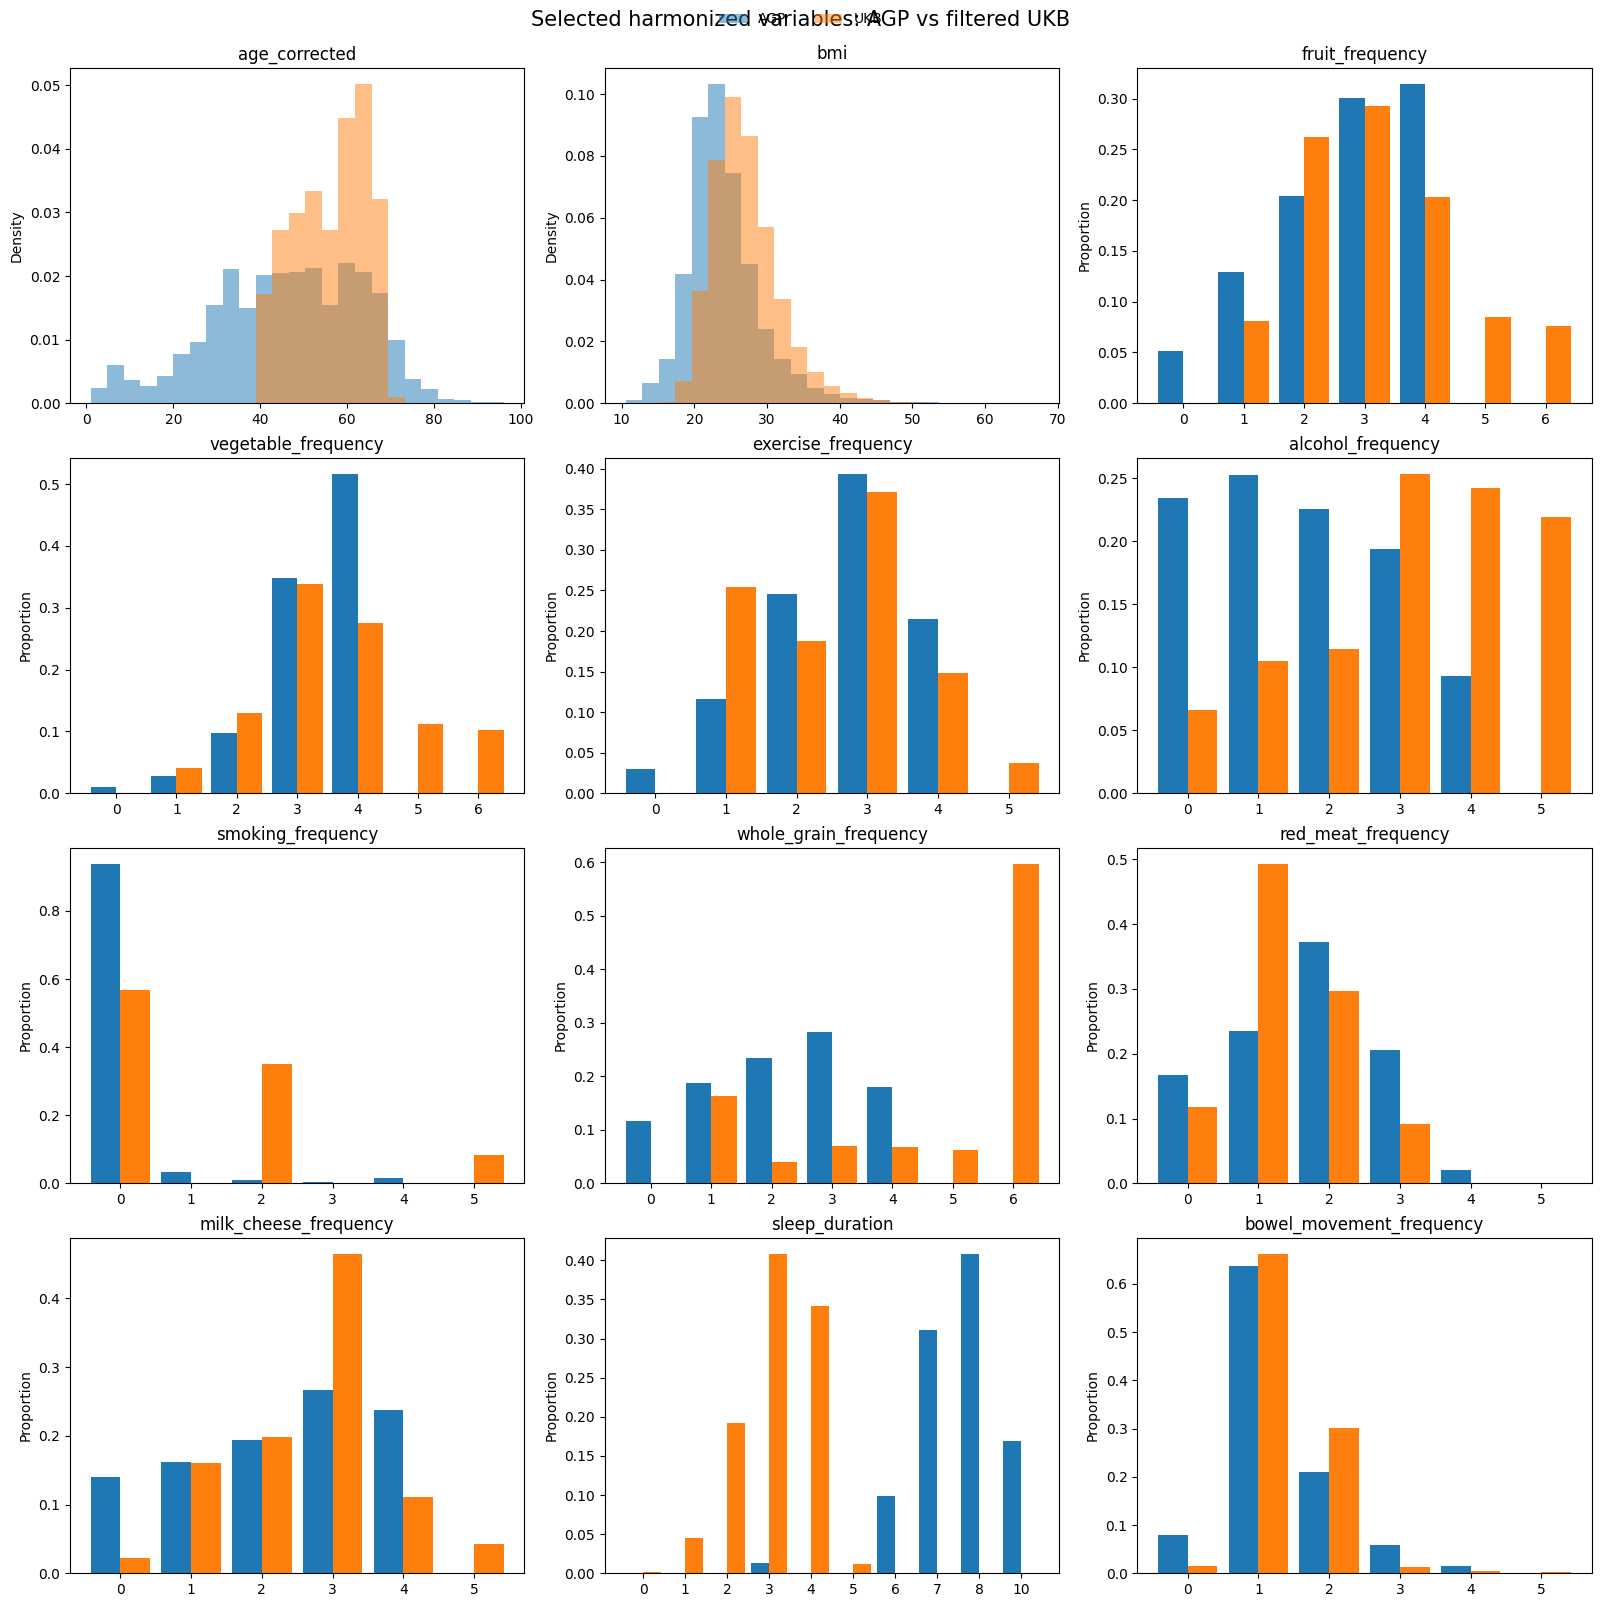

,column,type,agp_n_nonmissing,ukb_n_nonmissing,tv_distance,std_mean_diff,shift_score
0,sleep_duration,numeric_discrete,9559,118208,0.987342,NaN,0.987342
5,whole_grain_frequency,numeric_discrete,7583,118448,0.659403,NaN,0.659403
6,bmi,numeric_continuous,9559,118280,NaN,0.617219,0.617219
12,alcohol_frequency,numeric_discrete,9465,118422,0.428261,NaN,0.428261
13,smoking_frequency,numeric_discrete,9477,118262,0.423578,NaN,0.423578
15,vegetable_frequency,numeric_discrete,7632,118448,0.260346,NaN,0.260346
16,red_meat_frequency,numeric_discrete,7622,118300,0.259321,NaN,0.259321
17,milk_cheese_frequency,numeric_discrete,7643,116630,0.245997,NaN,0.245997
19,fruit_frequency,numeric_discrete,7623,118448,0.219292,NaN,0.219292
21,exercise_frequency,numeric_discrete,9438,72842,0.175046,NaN,0.175046


In [7]:

# -----------------------------
# Selected thesis-ready AGP vs UKB figure
# -----------------------------
selected_shared = [c for c in selected_vars if c in agp_df_cmp.columns and c in ukb_df_cmp.columns]
print("Selected shared variables:", selected_shared)

selected_png = comparison_out_dir / "selected_AGP_vs_UKB_variables.png"
selected_pdf = comparison_out_dir / "selected_AGP_vs_UKB_variables.pdf"

make_overlay_grid(
    agp_df_cmp,
    ukb_df_cmp,
    selected_shared,
    selected_png,
    selected_pdf,
    categorical_keep=categorical_keep,
    discrete_threshold=treat_numeric_as_categorical_if_unique_leq,
    ncols=3,
)

selected_drift_df = drift_df[drift_df["column"].isin(selected_shared)].copy()
selected_drift_df = selected_drift_df.sort_values("shift_score", ascending=False)
selected_drift_df.to_csv(comparison_out_dir / "selected_variable_drift_summary.csv", index=False)

selected_drift_df


### Raw-coded 3×3 AGP vs UKB comparison

This figure keeps the original AGP numeric coding for this panel only. In particular, AGP value `5` is **not** converted to missing for these plots, so the 0–5 distributions can be shown directly alongside the filtered UKB analytic sample.


Variables included in raw-coded 3x3 panel: ['age_corrected', 'bmi', 'fruit_frequency', 'vegetable_frequency', 'exercise_frequency', 'alcohol_frequency', 'red_meat_frequency', 'milk_cheese_frequency', 'bowel_movement_frequency']


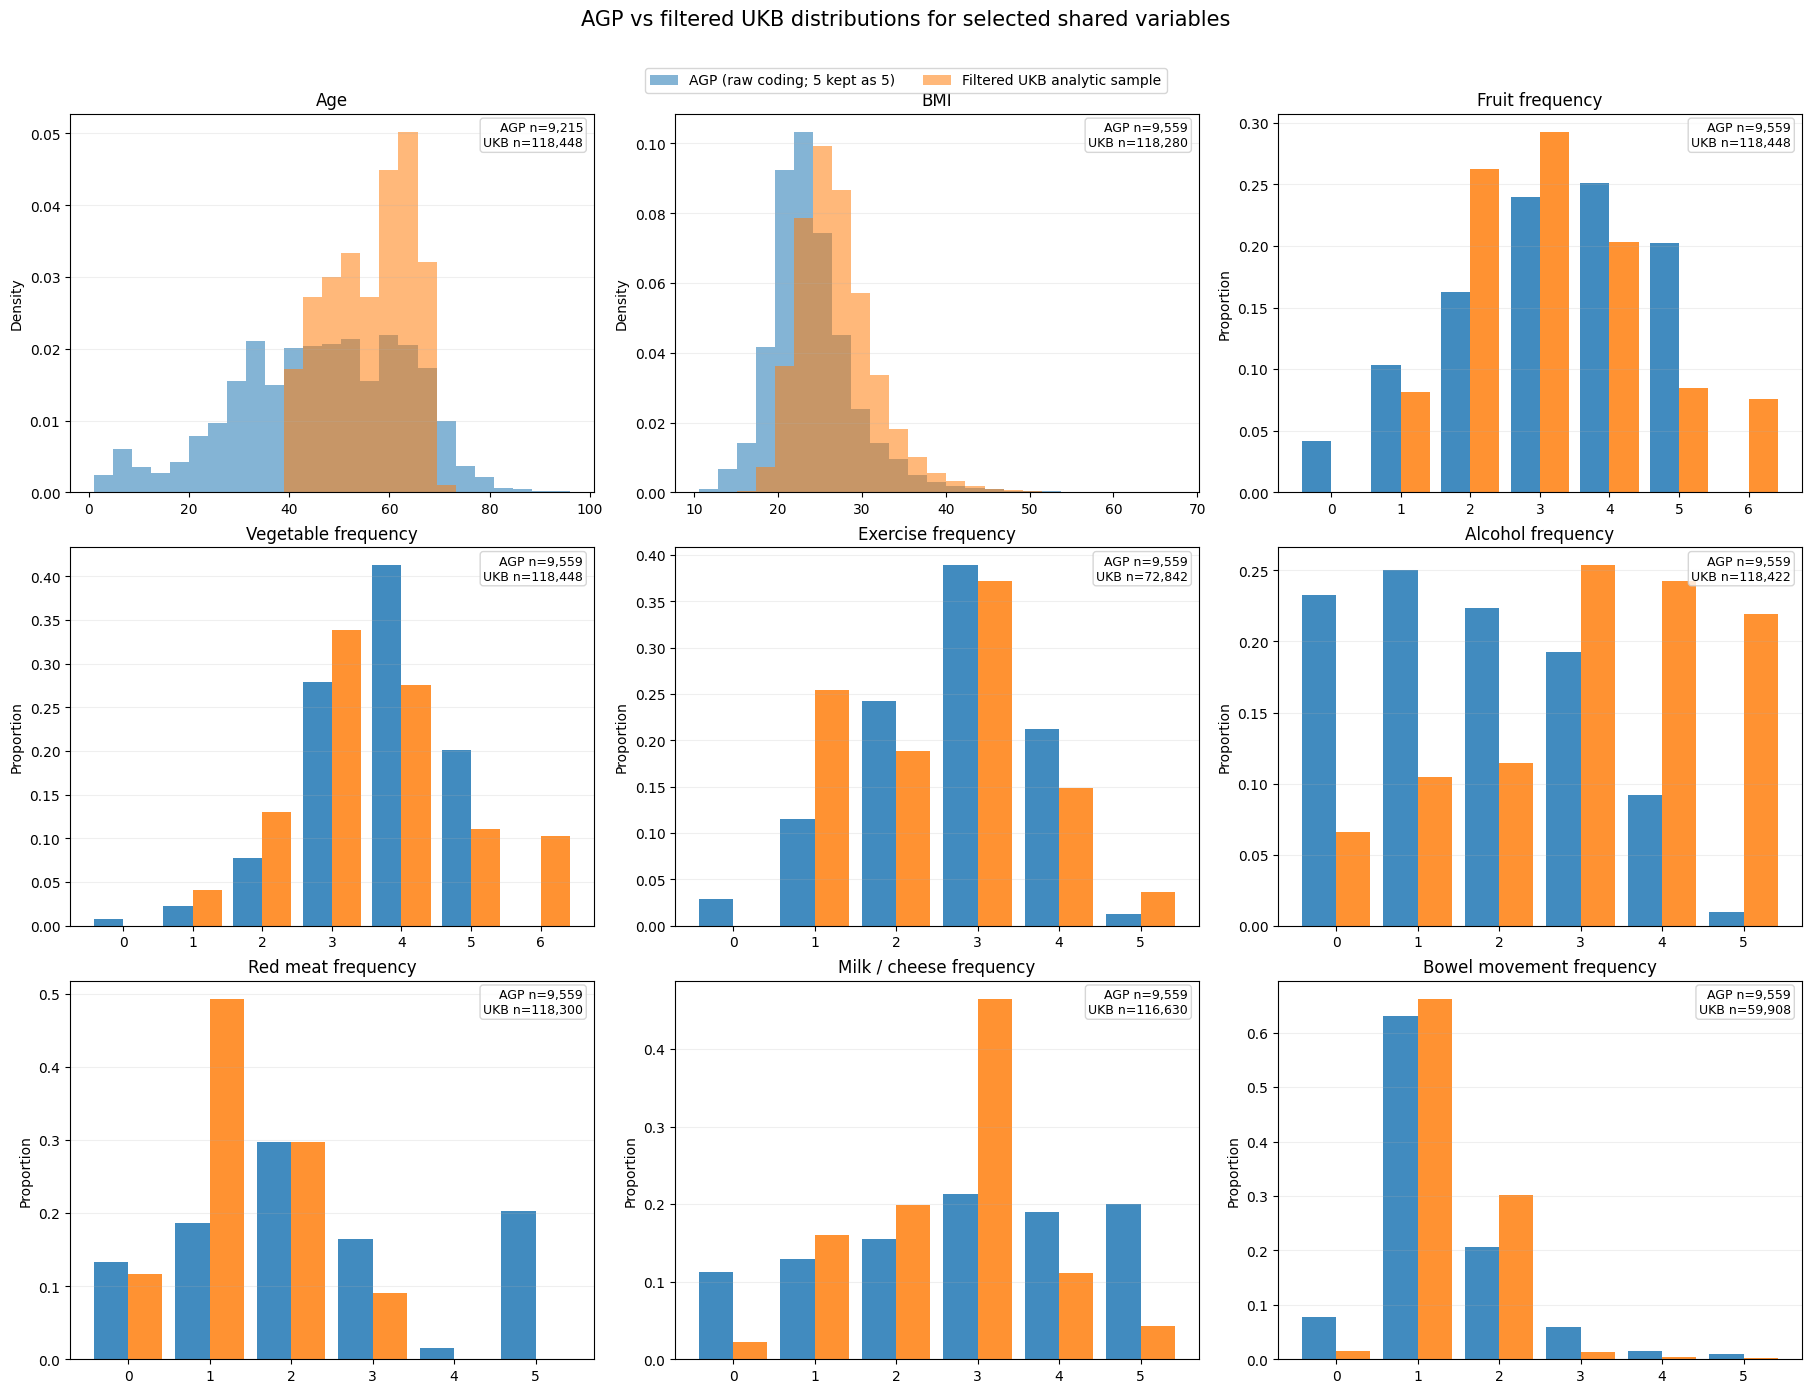

Saved raw-coded 3x3 PNG to: hongrui_result/UKB_RF_PCA_Projection/analytic_sample_agp_ukb_comparison/selected_AGP_vs_UKB_variables_rawcoding_3x3.png
Saved raw-coded 3x3 PDF to: hongrui_result/UKB_RF_PCA_Projection/analytic_sample_agp_ukb_comparison/selected_AGP_vs_UKB_variables_rawcoding_3x3.pdf


In [8]:

# -----------------------------
# Raw-coded 3x3 AGP vs UKB comparison
# For this figure only:
# - reload AGP metadata from disk
# - DO NOT convert AGP numeric value 5 to missing
# - keep the filtered UKB analytic sample used above
# -----------------------------
raw_compare_vars = [
    "age_corrected",
    "bmi",
    "fruit_frequency",
    "vegetable_frequency",
    "exercise_frequency",
    "alcohol_frequency",
    "red_meat_frequency",
    "milk_cheese_frequency",
    "bowel_movement_frequency",
]

pretty_var_names = {
    "age_corrected": "Age",
    "bmi": "BMI",
    "fruit_frequency": "Fruit frequency",
    "vegetable_frequency": "Vegetable frequency",
    "exercise_frequency": "Exercise frequency",
    "alcohol_frequency": "Alcohol frequency",
    "red_meat_frequency": "Red meat frequency",
    "milk_cheese_frequency": "Milk / cheese frequency",
    "bowel_movement_frequency": "Bowel movement frequency",
}

agp_df_raw_panel = pd.read_csv(agp_metadata_path, index_col=agp_index_col)

# Restrict to the same AGP microbiome-available subset when possible
if agp_otu_path.exists():
    otu_df_panel = pd.read_csv(agp_otu_path, index_col=otu_index_col)
    common_samples_panel = agp_df_raw_panel.index.intersection(otu_df_panel.index)
    agp_df_raw_panel = agp_df_raw_panel.loc[common_samples_panel].copy()

agp_df_raw_panel = force_numeric_everything_else(agp_df_raw_panel, categorical_keep)
ukb_df_panel = force_numeric_everything_else(ukb_df, categorical_keep)

panel_vars_present = [
    c for c in raw_compare_vars
    if c in agp_df_raw_panel.columns and c in ukb_df_panel.columns
]

print("Variables included in raw-coded 3x3 panel:", panel_vars_present)

raw_panel_png = comparison_out_dir / "selected_AGP_vs_UKB_variables_rawcoding_3x3.png"
raw_panel_pdf = comparison_out_dir / "selected_AGP_vs_UKB_variables_rawcoding_3x3.pdf"

fig, axes = plt.subplots(3, 3, figsize=(18, 13), constrained_layout=True)
axes = np.array(axes).reshape(-1)

legend_handles = None
legend_labels = None

for ax, col in zip(axes, panel_vars_present):
    s_agp = pd.to_numeric(agp_df_raw_panel[col], errors="coerce")
    s_ukb = pd.to_numeric(ukb_df_panel[col], errors="coerce")

    nunq = int(max(s_agp.dropna().nunique(), s_ukb.dropna().nunique()))
    title = pretty_var_names.get(col, col)

    if nunq <= treat_numeric_as_categorical_if_unique_leq:
        vc_agp = s_agp.dropna().value_counts(normalize=True).sort_index()
        vc_ukb = s_ukb.dropna().value_counts(normalize=True).sort_index()
        cats = sorted(set(vc_agp.index).union(set(vc_ukb.index)))
        xloc = np.arange(len(cats))
        width = 0.42

        bars1 = ax.bar(
            xloc - width / 2,
            vc_agp.reindex(cats, fill_value=0.0).values,
            width=width,
            alpha=0.85,
            label="AGP (raw coding; 5 kept as 5)"
        )
        bars2 = ax.bar(
            xloc + width / 2,
            vc_ukb.reindex(cats, fill_value=0.0).values,
            width=width,
            alpha=0.85,
            label="Filtered UKB analytic sample"
        )
        ax.set_xticks(xloc)
        ax.set_xticklabels([clean_num_tick(x) for x in cats])
        ax.set_ylabel("Proportion")
        if legend_handles is None:
            legend_handles = [bars1[0], bars2[0]]
            legend_labels = ["AGP", "Filtered UKB"]
    else:
        x = s_agp.dropna().astype(float).to_numpy()
        y = s_ukb.dropna().astype(float).to_numpy()

        if len(x) > 0 and len(y) > 0:
            bins = np.histogram_bin_edges(np.concatenate([x, y]), bins=25)
            n1, bins1, patches1 = ax.hist(
                x, bins=bins, density=True, alpha=0.55,
                label="AGP (raw coding; 5 kept as 5)"
            )
            n2, bins2, patches2 = ax.hist(
                y, bins=bins, density=True, alpha=0.55,
                label="Filtered UKB analytic sample"
            )
            ax.set_ylabel("Density")
            if legend_handles is None and len(patches1) > 0 and len(patches2) > 0:
                legend_handles = [patches1[0], patches2[0]]
                legend_labels = ["AGP (raw coding; 5 kept as 5)", "Filtered UKB analytic sample"]
        else:
            ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center")
            ax.set_axis_off()
            continue

    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.2, axis="y")
    ax.text(
        0.98, 0.98,
        f"AGP n={int(s_agp.notna().sum()):,}\nUKB n={int(s_ukb.notna().sum()):,}",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="0.8")
    )

for ax in axes[len(panel_vars_present):]:
    ax.set_axis_off()

if legend_handles is not None:
    fig.legend(
        legend_handles, legend_labels,
        loc="upper center", ncol=2, frameon=True, bbox_to_anchor=(0.5, 1.02)
    )

fig.suptitle(
    "AGP vs filtered UKB distributions for selected shared variables\n",
    fontsize=15, y=1.06
)

fig.savefig(raw_panel_png, dpi=300, bbox_inches="tight")
fig.savefig(raw_panel_pdf, bbox_inches="tight")
plt.show()

print(f"Saved raw-coded 3x3 PNG to: {raw_panel_png}")
print(f"Saved raw-coded 3x3 PDF to: {raw_panel_pdf}")


In [9]:

# -----------------------------
# Load or rebuild projected UKB microbiome PCs
# -----------------------------
pc_hat = load_or_predict_projected_pcs(
    ukb_df=ukb_df,
    train_cols=train_cols,
    n_pcs_to_predict=n_pcs_to_predict,
    final_rf_models=final_rf_models,
    projection_out_dir=projection_out_dir,
)

print(pc_hat.shape)
pc_hat.head()


Loading existing projected PCs from: hongrui_result/UKB_RF_PCA_Projection/ukb_predicted_microbiome_pcs.csv
(118448, 10)


,PC1_hat,PC2_hat,PC3_hat,PC4_hat,PC5_hat,PC6_hat,PC7_hat,PC8_hat,PC9_hat,PC10_hat
sample_name,,,,,,,,,,
1024551.0,-0.579523,0.316541,-0.291181,0.062910,0.263267,0.163138,-0.247535,0.144368,0.092079,0.579773
1026321.0,0.043869,-0.111364,1.028300,0.441964,0.128480,0.124880,-0.261751,0.382357,0.782332,0.540317
1026624.0,0.519928,-0.868541,1.179226,0.865442,-0.080527,0.485234,-0.002136,-0.116164,0.688413,0.760691
1040224.0,0.432357,0.113647,0.087198,0.251020,0.336492,-0.256395,-0.256614,0.416491,0.535529,0.444438
1055328.0,0.757858,-0.722345,1.064083,0.001806,0.064161,0.514661,-0.368272,-0.363279,-0.004009,0.495215


In [10]:

# -----------------------------
# Summarize and plot projected microbiome features
# -----------------------------
pc_summary = summarize_projected_pcs(pc_hat)
pc_summary.to_csv(comparison_out_dir / "ukb_projected_pcs_summary.csv", index=False)
pc_summary


,PC,N,Mean,SD,Median,Q1,Q3,Min,Max
0,PC1_hat,118448,-0.170647,1.169680,-0.179946,-0.969868,0.621188,-5.054035,4.757080
1,PC2_hat,118448,-0.294848,0.440759,-0.280789,-0.595000,0.019664,-2.293110,1.327356
2,PC3_hat,118448,0.051750,0.853931,0.041663,-0.611388,0.801074,-3.006201,2.870923
3,PC4_hat,118448,0.310438,0.393229,0.301088,0.056082,0.553603,-1.545041,2.582892
4,PC5_hat,118448,0.343876,0.379410,0.291094,0.076902,0.555664,-0.883727,2.097752
5,PC6_hat,118448,0.186860,0.360562,0.210288,-0.098365,0.466315,-0.875116,1.667196
6,PC7_hat,118448,-0.189443,0.201650,-0.201767,-0.330480,-0.059431,-1.140352,1.033962
7,PC8_hat,118448,0.069228,0.381763,0.120336,-0.172140,0.356820,-1.871518,1.371812
8,PC9_hat,118448,0.479015,0.240934,0.483923,0.315733,0.641011,-0.780837,1.576993
9,PC10_hat,118448,0.520605,0.151047,0.527220,0.431356,0.617911,-0.649019,1.299847


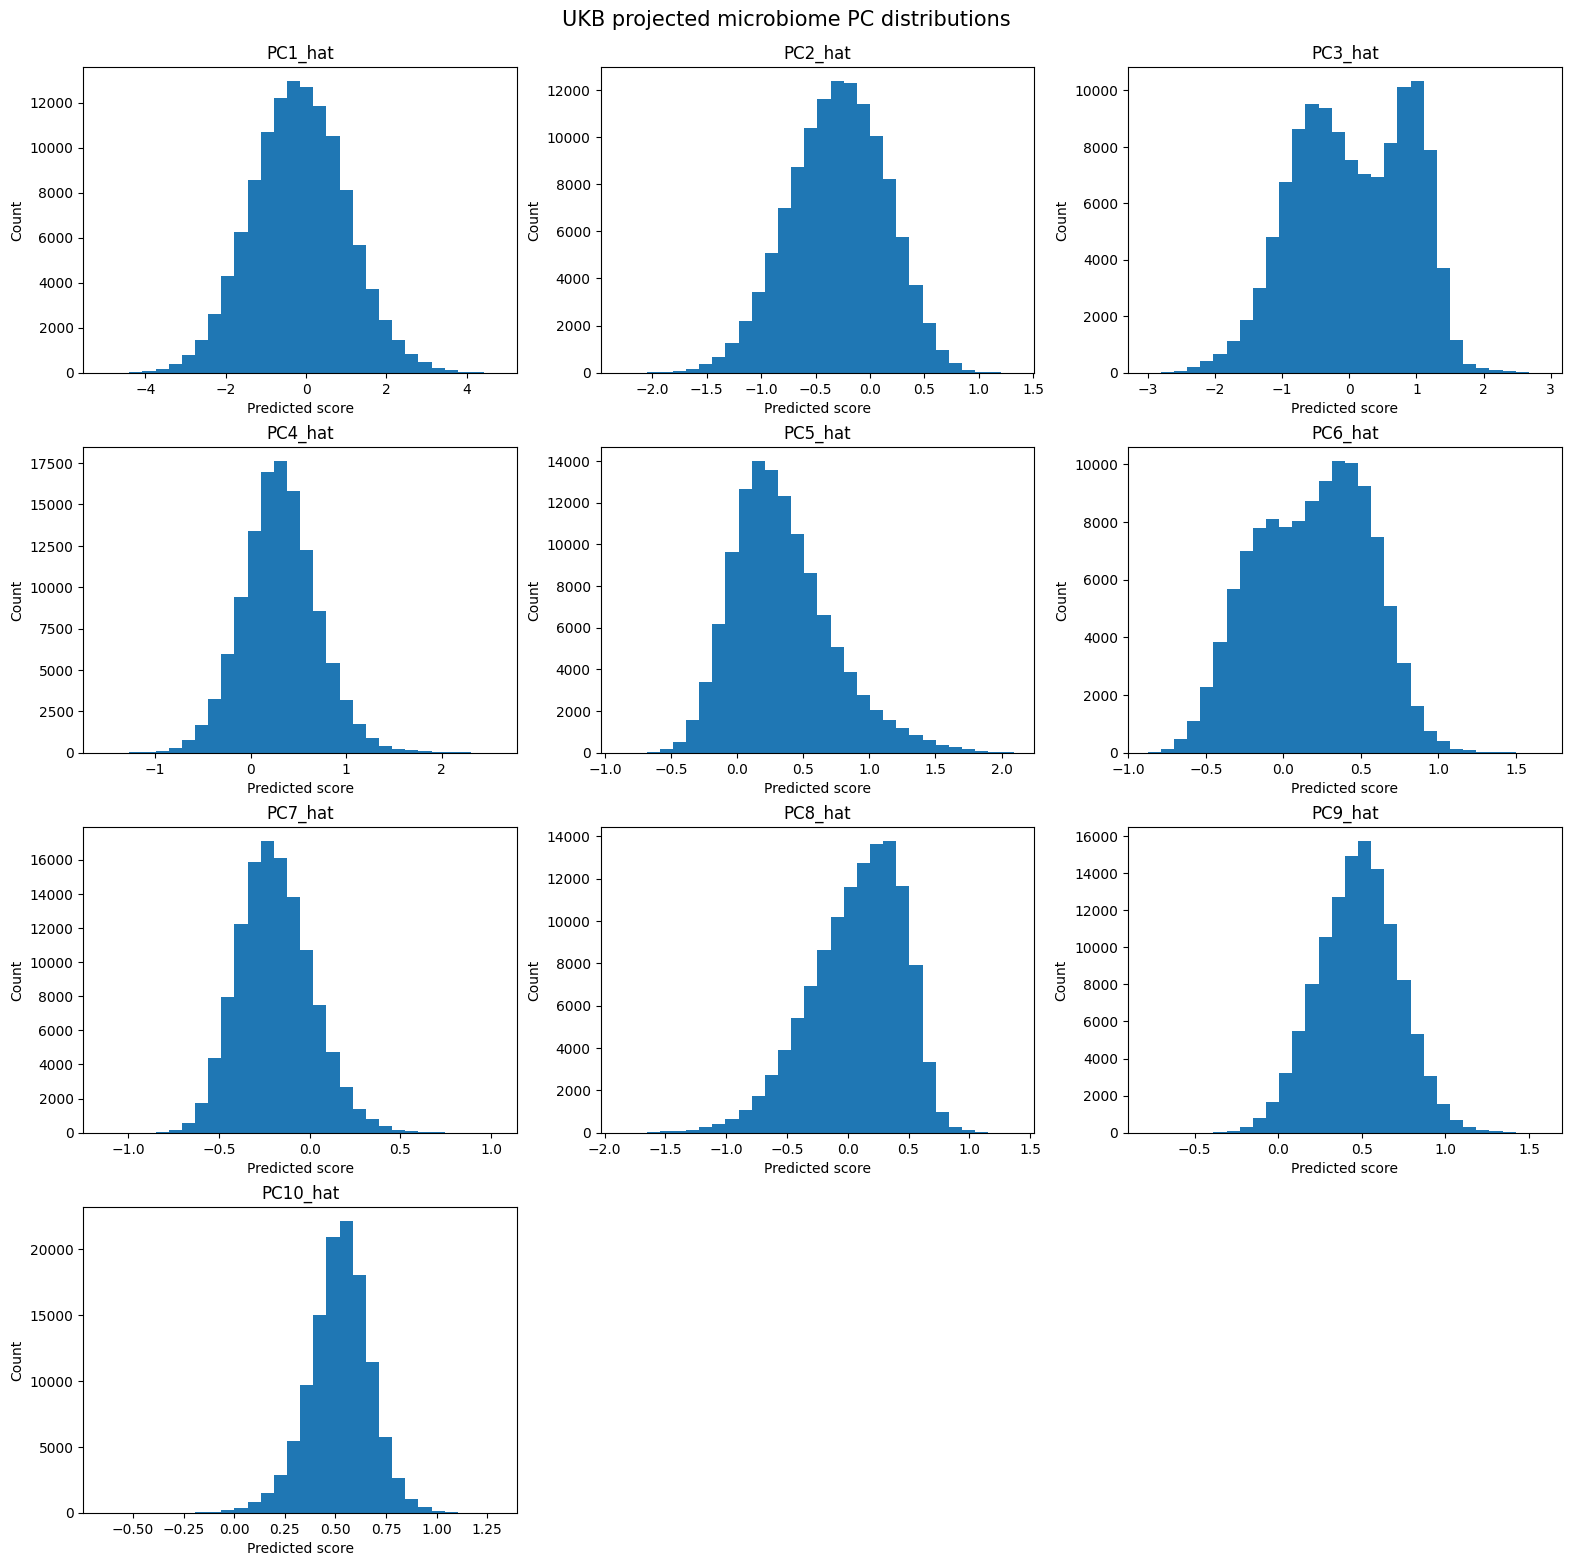

In [11]:

plot_projected_pc_distributions(
    pc_hat,
    out_png=comparison_out_dir / "ukb_projected_pc_distributions.png",
    out_pdf=comparison_out_dir / "ukb_projected_pc_distributions.pdf",
    max_show=min(10, pc_hat.shape[1]),
    ncols=3,
)


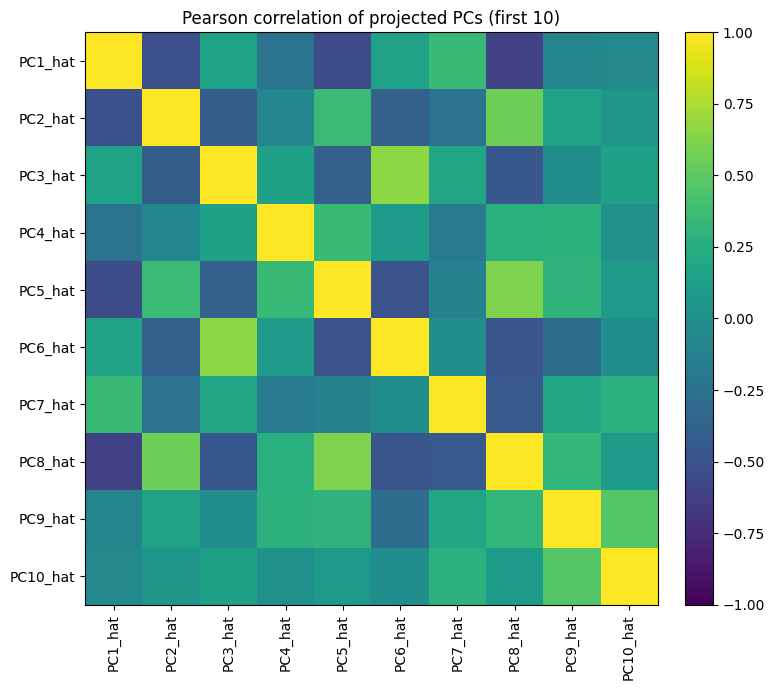

,PC1_hat,PC2_hat,PC3_hat,PC4_hat,PC5_hat,PC6_hat,PC7_hat,PC8_hat,PC9_hat,PC10_hat
PC1_hat,1.000,-0.508,0.161,-0.231,-0.532,0.153,0.350,-0.607,-0.086,-0.062
PC2_hat,-0.508,1.000,-0.409,-0.072,0.363,-0.386,-0.240,0.560,0.151,0.055
PC3_hat,0.161,-0.409,1.000,0.148,-0.384,0.659,0.175,-0.453,-0.016,0.148
PC4_hat,-0.231,-0.072,0.148,1.000,0.356,0.095,-0.184,0.268,0.283,0.005
PC5_hat,-0.532,0.363,-0.384,0.356,1.000,-0.487,-0.131,0.612,0.299,0.083
PC6_hat,0.153,-0.386,0.659,0.095,-0.487,1.000,-0.020,-0.476,-0.276,-0.017
PC7_hat,0.350,-0.240,0.175,-0.184,-0.131,-0.020,1.000,-0.443,0.197,0.278
PC8_hat,-0.607,0.560,-0.453,0.268,0.612,-0.476,-0.443,1.000,0.326,0.089
PC9_hat,-0.086,0.151,-0.016,0.283,0.299,-0.276,0.197,0.326,1.000,0.468
PC10_hat,-0.062,0.055,0.148,0.005,0.083,-0.017,0.278,0.089,0.468,1.000


In [12]:

pc_corr = plot_projected_pc_corr(
    pc_hat,
    out_png=comparison_out_dir / "ukb_projected_pc_corr_heatmap.png",
    out_pdf=comparison_out_dir / "ukb_projected_pc_corr_heatmap.pdf",
    max_show=min(10, pc_hat.shape[1]),
)

pc_corr.round(3)



## Suggested use for Section 4.6

The outputs from this notebook let you support two linked points:

1. **UKB analytic sample definition**  
   Use `sample_flow_ukb.csv` and `compact_demographics_agp_vs_ukb.csv`.

2. **Cross-cohort predictor comparability**  
   Use `selected_AGP_vs_UKB_variables.png/pdf` in the main text, and cite the broader multipage PDF plus drift summary as supplementary/QC material.

A simple reporting pattern is:
- first state the final UKB analytic sample size after row filtering,
- then show that the major recoded lifestyle variables have broadly similar distributions across AGP and UKB,
- then show the distribution/correlation structure of the projected microbiome PCs in UKB.


Features summarized: 27
['alcohol_consumption', 'appendix_removed', 'lactose', 'alcohol_frequency', 'exercise_frequency', 'flossing_frequency', 'fruit_frequency', 'high_fat_red_meat_frequency', 'milk_cheese_frequency', 'milk_substitute_frequency', 'one_liter_of_water_a_day_frequency', 'poultry_frequency', 'probiotic_frequency', 'red_meat_frequency', 'salted_snacks_frequency', 'seafood_frequency', 'smoking_frequency', 'teethbrushing_frequency', 'vegetable_frequency', 'vitamin_b_supplement_frequency', 'vitamin_d_supplement_frequency', 'whole_grain_frequency', 'bowel_movement_frequency', 'sleep_duration', 'sex', 'bmi', 'weight_kg']


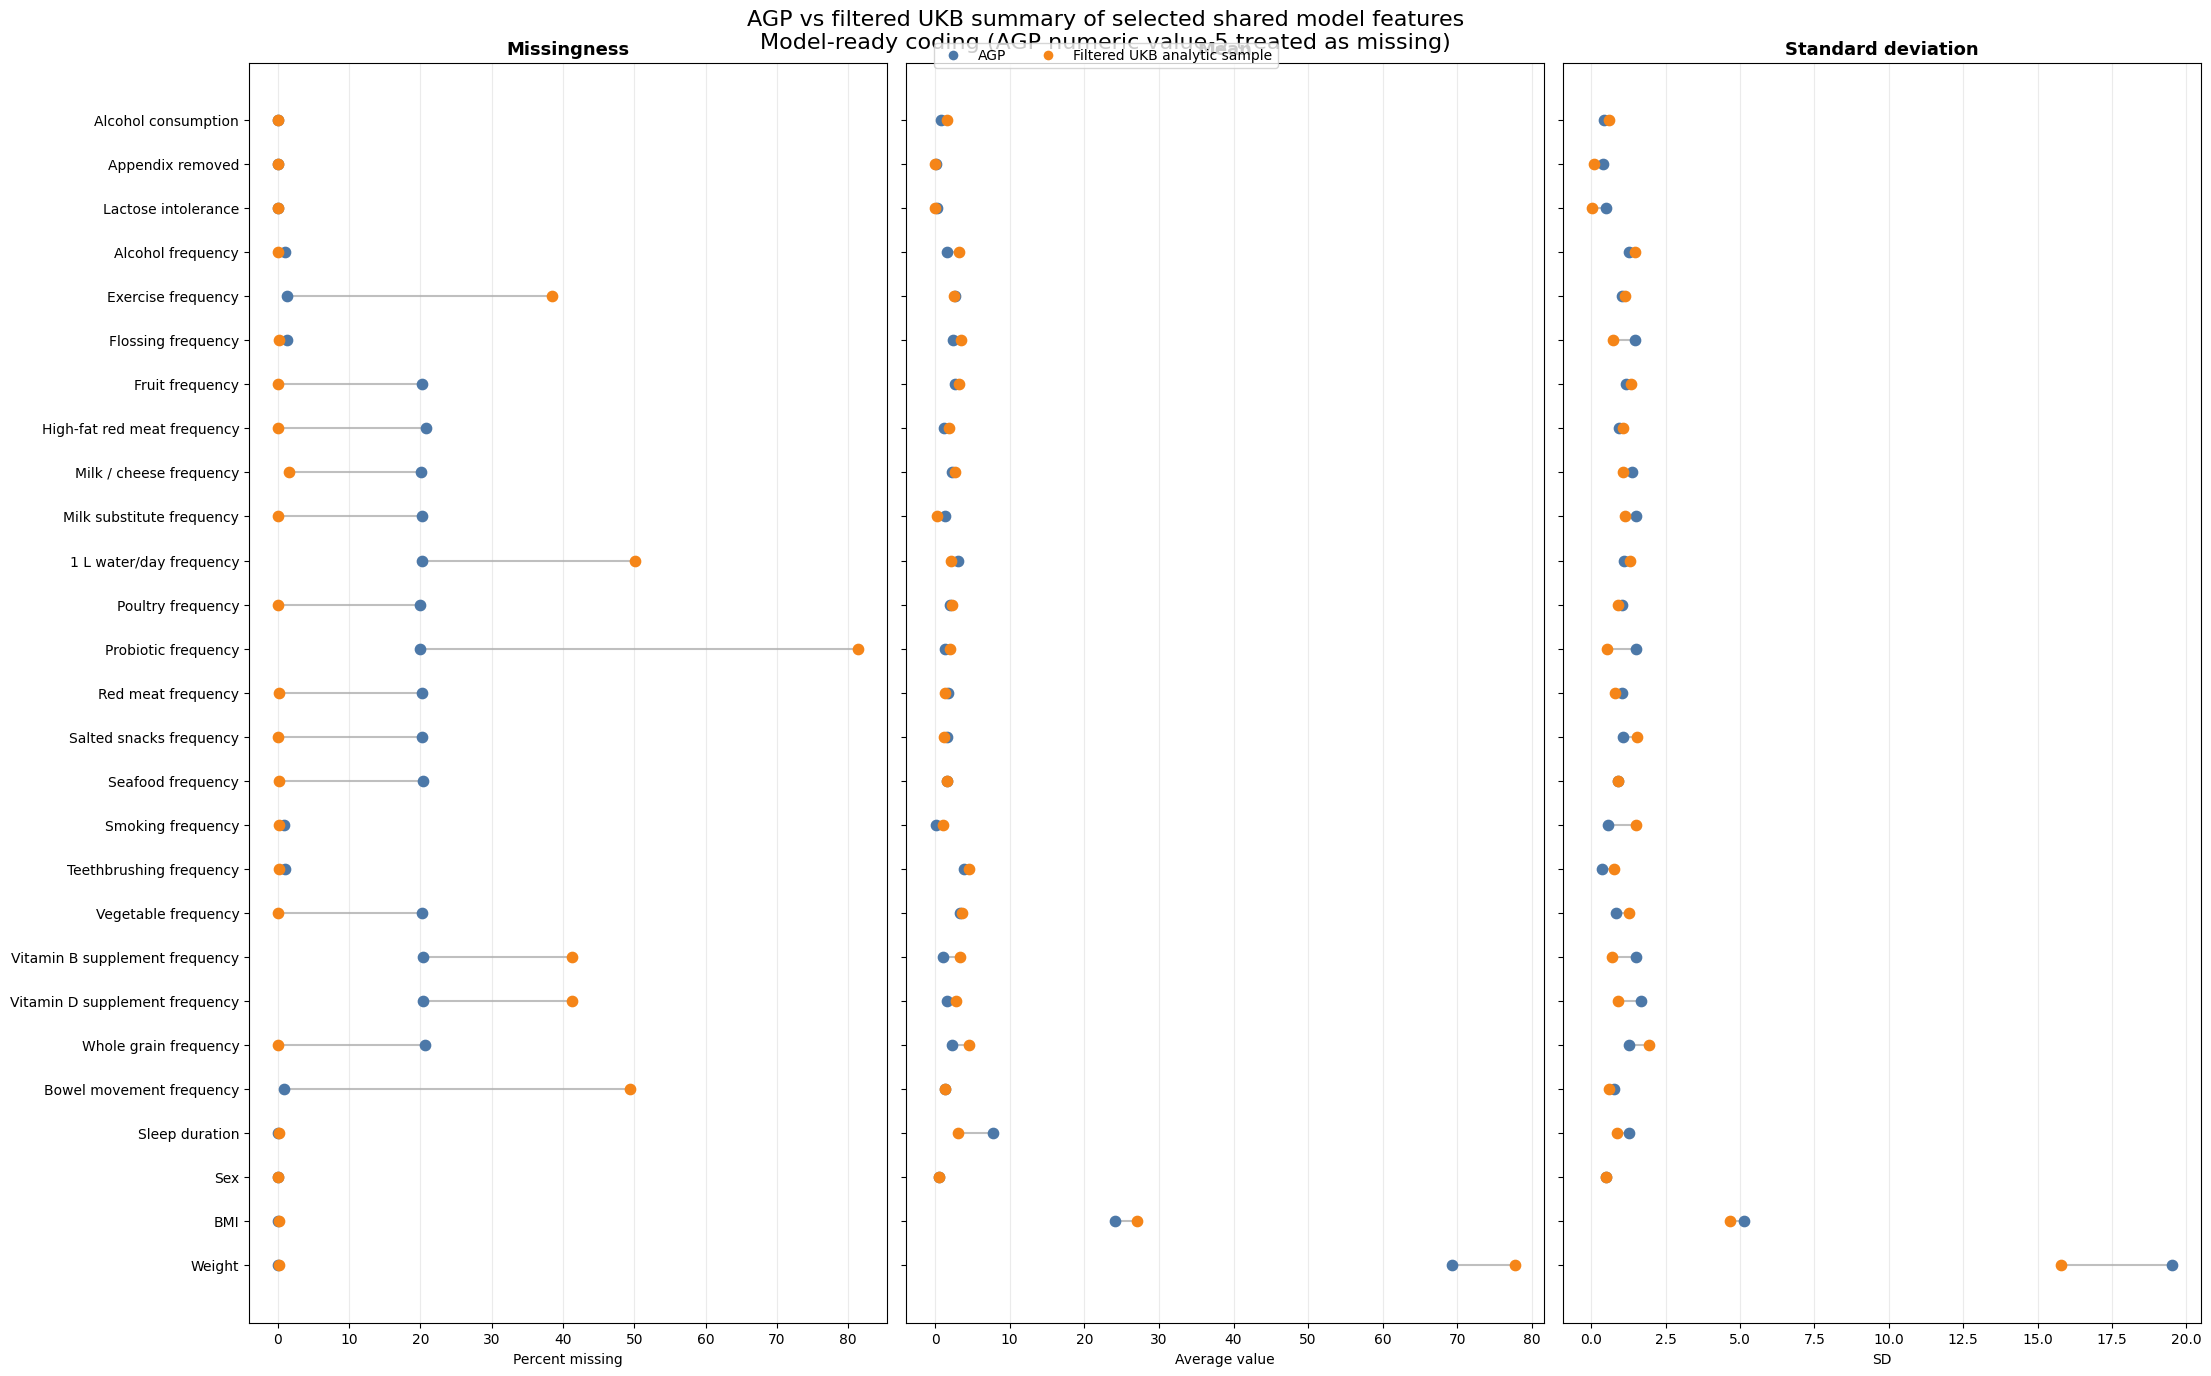

Saved summary table to: hongrui_result/UKB_RF_PCA_Projection/analytic_sample_agp_ukb_comparison/all_selected_features_missingness_mean_sd.csv
Saved summary figure to: hongrui_result/UKB_RF_PCA_Projection/analytic_sample_agp_ukb_comparison/all_selected_features_summary_missingness_mean_sd.png
Saved summary figure to: hongrui_result/UKB_RF_PCA_Projection/analytic_sample_agp_ukb_comparison/all_selected_features_summary_missingness_mean_sd.pdf


,feature,label,AGP_n,AGP_missing_pct,AGP_mean,AGP_sd,UKB_n,UKB_missing_pct,UKB_mean,UKB_sd
0,alcohol_consumption,Alcohol consumption,9559,0.00,0.78,0.44,118422,0.02,1.65,0.60
1,appendix_removed,Appendix removed,9559,0.00,0.14,0.39,118448,0.00,0.01,0.11
2,lactose,Lactose intolerance,9559,0.00,0.22,0.49,118448,0.00,0.00,0.03
3,alcohol_frequency,Alcohol frequency,9465,0.98,1.66,1.28,118422,0.02,3.16,1.49
4,exercise_frequency,Exercise frequency,9438,1.27,2.65,1.03,72842,38.50,2.52,1.13
5,flossing_frequency,Flossing frequency,9434,1.31,2.43,1.46,118335,0.10,3.52,0.74
6,fruit_frequency,Fruit frequency,7623,20.25,2.70,1.19,118448,0.00,3.18,1.33
7,high_fat_red_meat_frequency,High-fat red meat frequency,7571,20.80,1.22,0.94,118392,0.05,1.85,1.06
8,milk_cheese_frequency,Milk / cheese frequency,7643,20.04,2.30,1.36,116630,1.53,2.61,1.08
9,milk_substitute_frequency,Milk substitute frequency,7626,20.22,1.31,1.51,118420,0.02,0.28,1.15


In [13]:
# -----------------------------
# Summary of all selected training features:
# missingness, mean, and SD
# Uses model-ready coding already loaded above
# -----------------------------
summary_features = [
    c for c in train_cols
    if c in agp_df_cmp.columns and c in ukb_df_cmp.columns
]

print(f"Features summarized: {len(summary_features)}")
print(summary_features)

feature_label_map = {
    "age_corrected": "Age",
    "bmi": "BMI",
    "weight_kg": "Weight",
    "sex": "Sex",
    "alcohol_consumption": "Alcohol consumption",
    "appendix_removed": "Appendix removed",
    "lactose": "Lactose intolerance",
    "alcohol_frequency": "Alcohol frequency",
    "exercise_frequency": "Exercise frequency",
    "flossing_frequency": "Flossing frequency",
    "frozen_dessert_frequency": "Frozen dessert frequency",
    "fruit_frequency": "Fruit frequency",
    "high_fat_red_meat_frequency": "High-fat red meat frequency",
    "milk_cheese_frequency": "Milk / cheese frequency",
    "milk_substitute_frequency": "Milk substitute frequency",
    "one_liter_of_water_a_day_frequency": "1 L water/day frequency",
    "poultry_frequency": "Poultry frequency",
    "probiotic_frequency": "Probiotic frequency",
    "red_meat_frequency": "Red meat frequency",
    "salted_snacks_frequency": "Salted snacks frequency",
    "seafood_frequency": "Seafood frequency",
    "smoking_frequency": "Smoking frequency",
    "teethbrushing_frequency": "Teethbrushing frequency",
    "vegetable_frequency": "Vegetable frequency",
    "vitamin_b_supplement_frequency": "Vitamin B supplement frequency",
    "vitamin_d_supplement_frequency": "Vitamin D supplement frequency",
    "whole_eggs": "Whole eggs",
    "whole_grain_frequency": "Whole grain frequency",
    "bowel_movement_frequency": "Bowel movement frequency",
    "sleep_duration": "Sleep duration",
}

summary_rows = []
for col in summary_features:
    s_agp = pd.to_numeric(agp_df_cmp[col], errors="coerce")
    s_ukb = pd.to_numeric(ukb_df_cmp[col], errors="coerce")

    summary_rows.append({
        "feature": col,
        "label": feature_label_map.get(col, col.replace("_", " ").title()),
        "AGP_n": int(s_agp.notna().sum()),
        "AGP_missing_pct": float(s_agp.isna().mean() * 100.0),
        "AGP_mean": float(s_agp.mean()),
        "AGP_sd": float(s_agp.std(ddof=1)),
        "UKB_n": int(s_ukb.notna().sum()),
        "UKB_missing_pct": float(s_ukb.isna().mean() * 100.0),
        "UKB_mean": float(s_ukb.mean()),
        "UKB_sd": float(s_ukb.std(ddof=1)),
    })

feature_summary_df = pd.DataFrame(summary_rows)

# Save detailed table
feature_summary_csv = comparison_out_dir / "all_selected_features_missingness_mean_sd.csv"
feature_summary_df.to_csv(feature_summary_csv, index=False)

# Word-friendly rounded display copy
feature_summary_display = feature_summary_df.copy()
for c in ["AGP_missing_pct", "AGP_mean", "AGP_sd", "UKB_missing_pct", "UKB_mean", "UKB_sd"]:
    feature_summary_display[c] = feature_summary_display[c].round(2)

feature_summary_display.to_csv(
    comparison_out_dir / "all_selected_features_missingness_mean_sd_rounded.csv",
    index=False
)

# Plot
plot_df = feature_summary_df.copy()
plot_df["label"] = pd.Categorical(plot_df["label"], categories=list(plot_df["label"]), ordered=True)
plot_df = plot_df.iloc[::-1].reset_index(drop=True)  # reverse for top-to-bottom reading

y = np.arange(len(plot_df))

summary_png = comparison_out_dir / "all_selected_features_summary_missingness_mean_sd.png"
summary_pdf = comparison_out_dir / "all_selected_features_summary_missingness_mean_sd.pdf"

fig, axes = plt.subplots(
    1, 3,
    figsize=(22, max(10, 0.42 * len(plot_df) + 2)),
    sharey=True,
    constrained_layout=True
)

agp_color = "#4C78A8"
ukb_color = "#F58518"

# Panel 1: missingness
ax = axes[0]
for i, row in plot_df.iterrows():
    ax.plot(
        [row["AGP_missing_pct"], row["UKB_missing_pct"]],
        [i, i],
        color="0.75", lw=1.5, zorder=1
    )
ax.scatter(plot_df["AGP_missing_pct"], y, s=55, color=agp_color, label="AGP", zorder=2)
ax.scatter(plot_df["UKB_missing_pct"], y, s=55, color=ukb_color, label="Filtered UKB", zorder=2)
ax.set_title("Missingness", fontsize=13, weight="bold")
ax.set_xlabel("Percent missing")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"])
ax.grid(axis="x", alpha=0.25)

# Panel 2: mean
ax = axes[1]
for i, row in plot_df.iterrows():
    ax.plot(
        [row["AGP_mean"], row["UKB_mean"]],
        [i, i],
        color="0.75", lw=1.5, zorder=1
    )
ax.scatter(plot_df["AGP_mean"], y, s=55, color=agp_color, zorder=2)
ax.scatter(plot_df["UKB_mean"], y, s=55, color=ukb_color, zorder=2)
ax.set_title("Mean", fontsize=13, weight="bold")
ax.set_xlabel("Average value")
ax.grid(axis="x", alpha=0.25)

# Panel 3: SD
ax = axes[2]
for i, row in plot_df.iterrows():
    ax.plot(
        [row["AGP_sd"], row["UKB_sd"]],
        [i, i],
        color="0.75", lw=1.5, zorder=1
    )
ax.scatter(plot_df["AGP_sd"], y, s=55, color=agp_color, zorder=2)
ax.scatter(plot_df["UKB_sd"], y, s=55, color=ukb_color, zorder=2)
ax.set_title("Standard deviation", fontsize=13, weight="bold")
ax.set_xlabel("SD")
ax.grid(axis="x", alpha=0.25)

fig.suptitle(
    "AGP vs filtered UKB summary of selected shared model features\n"
    "Model-ready coding (AGP numeric value 5 treated as missing)",
    fontsize=16,
    y=1.02
)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=agp_color, markersize=8, label="AGP"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=ukb_color, markersize=8, label="Filtered UKB analytic sample"),
]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=True, bbox_to_anchor=(0.5, 1.0))

fig.savefig(summary_png, dpi=300, bbox_inches="tight")
fig.savefig(summary_pdf, bbox_inches="tight")
plt.show()

print(f"Saved summary table to: {feature_summary_csv}")
print(f"Saved summary figure to: {summary_png}")
print(f"Saved summary figure to: {summary_pdf}")

feature_summary_display